# MSR Validation — Exploratory Pass

Explores the data and code artifacts collected by the mining layer of TestMap, and
runs the structural checks that must pass before any manual validation sampling.

This notebook is diagnostic. Its job is to find weaknesses in the collected data —
missing rows, unattributed observations, impossible values — so they can be fixed
before rater hours are spent. Every number here is free: no oracle, no raters.

Scope: this validates what TestMap **recorded and attributed**, not what the
underlying tools measured. Coverage rates and mutation statuses are taken from
`dotnet test` and Stryker as given.

Protocol and sampling design: `../msr_validation_plan.md`.

## Data Preparation

TestMap writes one SQLite database per repository revision. The `analysis` package
consolidates them into per-construct frames:

Two steps. First select the population and copy the qualifying repositories into a
validation corpus:

```powershell
uv run python -m analysis msr-population `
  --total "../Replication/FilteredTestRepoCollectTests/total" `
  --data  "../Replication/FilteredTestRepoCollectTests/data" `
  --out   msr-validation-data/population `
  --copy-to "../Replication/MSRValidation/data"
```

Then consolidate that corpus into per-construct frames:

```powershell
uv run python -m analysis build-msr-datasets `
  --db  "../Replication/MSRValidation/data" `
  --out "../Replication/MSRValidation"
```

`--db` accepts a directory (searched recursively for `analysis.db`), a glob, or an
explicit path, and may be repeated. `--limit N` reads only the first N databases,
which is the way to do a first pass over a corpus of this size.

Frames land in `<out>/frames/`. Rows are keyed by `repo_key` (`owner/repo@commit12`)
read from each database's `projects` table — member ids are per-database
autoincrement values and collide across repositories, so every join must carry it.

In [1]:
from pathlib import Path

import pandas as pd

import matplotlib.pyplot as plt

from analysis.msr_stats import (
    NUMERIC_COLUMNS,
    describe_numeric,
    iqr_table,
    summarize_checks,
    worst_repositories,
)
from analysis import msr_plots

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.axisbelow": True,
})

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")

FRAMES = Path("../../Replication/MSRValidation/frames")
POPULATION = Path("../msr-validation-data/population")

def load(name: str) -> pd.DataFrame:
    path = FRAMES / f"msr_{name}.csv"
    if not path.exists():
        print(f"[missing] {path} - run build-msr-datasets first")
        return pd.DataFrame()
    return pd.read_csv(path, low_memory=False)

repositories = load("repositories")
files        = load("files")
entities     = load("entities")
code_metrics = load("code_metrics")
test_smells  = load("test_smells")
coverage     = load("coverage")
mutants      = load("mutants")
mappings     = load("mappings")
checks       = load("structural_checks")

CONSTRUCT_FRAMES = {
    "entities": entities,
    "code_metrics": code_metrics,
    "test_smells": test_smells,
    "coverage": coverage,
    "mutants": mutants,
    "mappings": mappings,
}

pd.DataFrame(
    [{"frame": n, "rows": len(f), "repos": f["repo_key"].nunique() if not f.empty else 0}
     for n, f in CONSTRUCT_FRAMES.items()]
)

,frame,rows,repos
0,entities,616718,197
1,code_metrics,614784,197
2,test_smells,89084,196
3,coverage,245806,197
4,mutants,81646,115
5,mappings,158784,184


## Pipeline Outcomes And Population Selection

Not every target produced data worth validating. Targets in `failed-total.yaml`
never reported back and are counted as **timeouts**; the rest carry a pipeline
status and a failure stage.

Selection uses the per-repository validation flags, which cascade
(`Restores` >= `Builds` >= `TestsRun` >= `HasCoverage` >= `HasMutationScore`):

- **eligible_core** — restored, built, ran tests, produced coverage. The frame for
  code metrics, test smells, coverage, and mappings.
- **eligible_mutation** — produced a mutation score. The frame for mutants only.

Everything else is excluded and does not appear in the frames loaded above.

In [2]:
def load_population(name: str) -> pd.DataFrame:
    path = POPULATION / f"msr_{name}.csv"
    if not path.exists():
        print(f"[missing] {path} - run msr-population first")
        return pd.DataFrame()
    return pd.read_csv(path)

outcomes   = load_population("outcomes")
failures   = load_population("failure_reasons")
capability = load_population("capabilities")
selection  = load_population("selection")
exclusions = load_population("exclusions")

display(outcomes)
display(failures)

,outcome,targets,share
0,completed,912,0.7042
1,failed,224,0.173
2,timeout,159,0.1228


,outcome,failure_reason,targets,share_of_all,share_of_failed
0,timeout,timeout (failed manifest),159,0.1228,0.4151
1,failed,materialization: Failed,145,0.112,0.3786
2,failed,pipeline: NotSupportedException,24,0.01853,0.06266
3,failed,pipeline: NullReferenceException,18,0.0139,0.047
4,failed,pipeline: ArgumentOutOfRangeException,10,0.007722,0.02611
5,failed,materialization: WorkspaceDirty,5,0.003861,0.01305
6,failed,coordinator: UnauthorizedAccessException,4,0.003089,0.01044
7,failed,Materialized,4,0.003089,0.01044
8,failed,materialization: RepositoryUnavailable,3,0.002317,0.007833
9,failed,coordinator: IOException,2,0.001544,0.005222


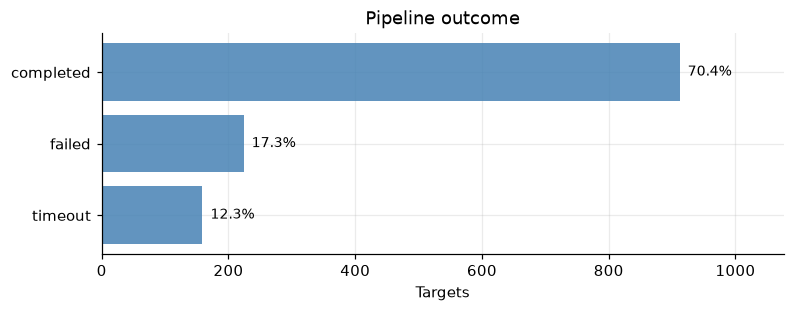

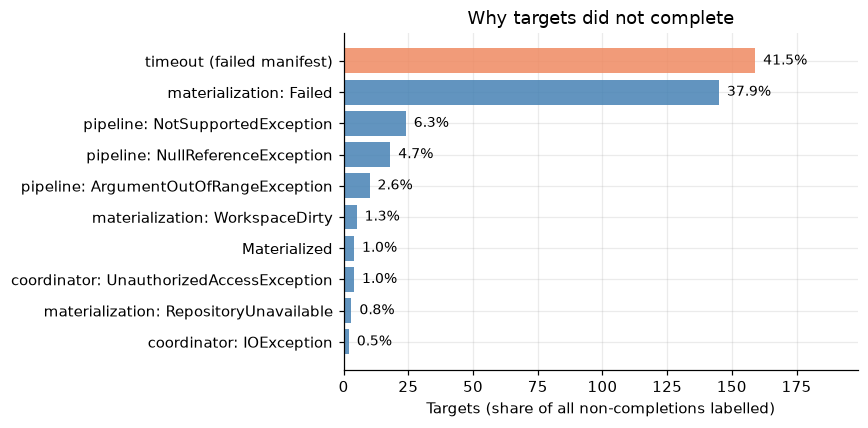

In [3]:
msr_plots.outcome_bar(outcomes)
plt.show()
msr_plots.failure_reason_bar(failures)
plt.tight_layout()
plt.show()

In [4]:
# Capability shares over completed targets: the denominator that can actually
# reach these states. Reported over all targets as well, since the manifest is
# the population a reader will assume.
display(capability)
display(selection)
display(exclusions)

,capability,repositories,denominator,share
0,Restores,346,912,0.3794
1,Builds,346,912,0.3794
2,TestsRun,346,912,0.3794
3,TestsPass,140,912,0.1535
4,HasCoverage,344,912,0.3772
5,HasMutationScore,169,912,0.1853


,population,constructs,repositories,share_of_targets
0,eligible_core,"metrics, smells, coverage, mappings",344,0.2656
1,eligible_mutation,mutants,169,0.1305
2,selected (union),copied to the validation corpus,344,0.2656
3,selected with analysis.db,actually readable,344,0.2656


,exclusion_reason,targets,share_of_all
0,failed Restores,565,0.4363
1,not completed: failed,224,0.173
2,not completed: timeout,159,0.1228
3,failed HasCoverage,2,0.001544
4,no validation row,1,0.0007722


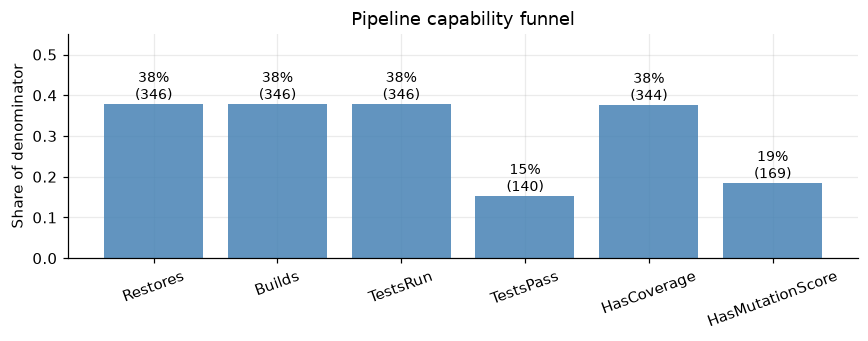

In [5]:
# Capability order is the cascade order, so the bars read as a funnel: each step
# can only lose repositories, and the size of a drop names the stage that costs most.
msr_plots.capability_funnel(capability)
plt.tight_layout()
plt.show()

## Study Population And Data Availability

Not every repository carries every construct. Static analysis runs on all of them,
but coverage and mutation only exist where the test suite built and ran, so the
denominators differ per construct. Everything downstream — sampling frames, rates,
per-construct budgets — depends on knowing these counts first.

,repositories,with_data,share
code_metrics,197,197,1
test_smells,197,196,0.9949
coverage,197,197,1
mutants,197,116,0.5888
mappings,197,184,0.934


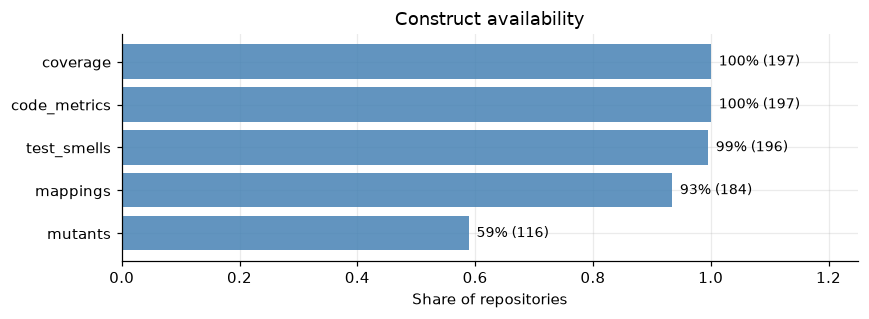

In [6]:
availability = pd.DataFrame({
    "repositories": [len(repositories)] * 5,
    "with_data": [
        int(repositories["has_metrics"].sum()),
        int(repositories["has_smells"].sum()),
        int(repositories["has_coverage"].sum()),
        int(repositories["has_mutants"].sum()),
        int(repositories["has_mappings"].sum()),
    ],
}, index=["code_metrics", "test_smells", "coverage", "mutants", "mappings"])
availability["share"] = availability["with_data"] / availability["repositories"]
display(availability)

msr_plots.availability_bar(availability)
plt.tight_layout()
plt.show()

In [7]:
# Repositories where static analysis produced nothing at all: these are not a
# sampling population, they are a pipeline failure to account for separately.
empty = repositories[repositories["members"] == 0]
print(f"repositories with zero members: {len(empty)} of {len(repositories)}")

size_cols = ["files", "objects", "members", "test_members", "code_metrics",
             "test_smells", "coverage_rows", "mutants", "mappings"]
repositories[size_cols].sum().to_frame("corpus_total")

repositories with zero members: 0 of 197


,corpus_total
files,60121
objects,82354
members,534364
test_members,69345
code_metrics,614784
test_smells,89084
coverage_rows,245806
mutants,672354
mappings,158784


## Structural Checks

Each check is a rate with an explicit numerator and denominator, computed per
repository and pooled here. Three severities:

- **defect** — the row cannot be correct as stored (orphan foreign key, duplicate
  attribution, value out of range, a line outside its member's span);
- **coverage_gap** — the row is absent rather than wrong (a member with no metric
  row, a mutant with no member attribution);
- **suspect** — worth a look, not necessarily wrong.

Rates pool numerators and denominators across repositories rather than averaging
per-repo rates, so a large repository counts for more than a tiny one.

A repository that never collected a construct is excluded from that construct's gap
rate — that is an availability fact, recorded above, and folding it in here would
swamp the real missing-row rate.

,construct,check,severity,repositories,repositories_affected,numerator,denominator,rate
0,mutants,mutants_containment_violation,defect,115,115,10241,572836,0.01788
1,mappings,mappings_duplicate_pair,defect,184,49,794,158784,0.005001
13,mutants,members_missing_mutants,coverage_gap,116,116,211988,292704,0.7242
14,coverage,members_missing_coverage,coverage_gap,197,197,326226,534364,0.6105
15,mutants,mutants_unattributed,coverage_gap,116,63,99518,672354,0.148
16,test_smells,smells_unattributed,coverage_gap,196,140,2326,89084,0.02611
17,code_metrics,members_missing_metrics,coverage_gap,197,84,1931,534364,0.003614
18,code_metrics,objects_missing_metrics,coverage_gap,197,2,3,82354,3.643e-05
21,coverage,coverage_lines_valid_zero,suspect,197,197,245806,245806,1
22,coverage,coverage_counts_missing_with_rate,suspect,197,190,113541,245806,0.4619


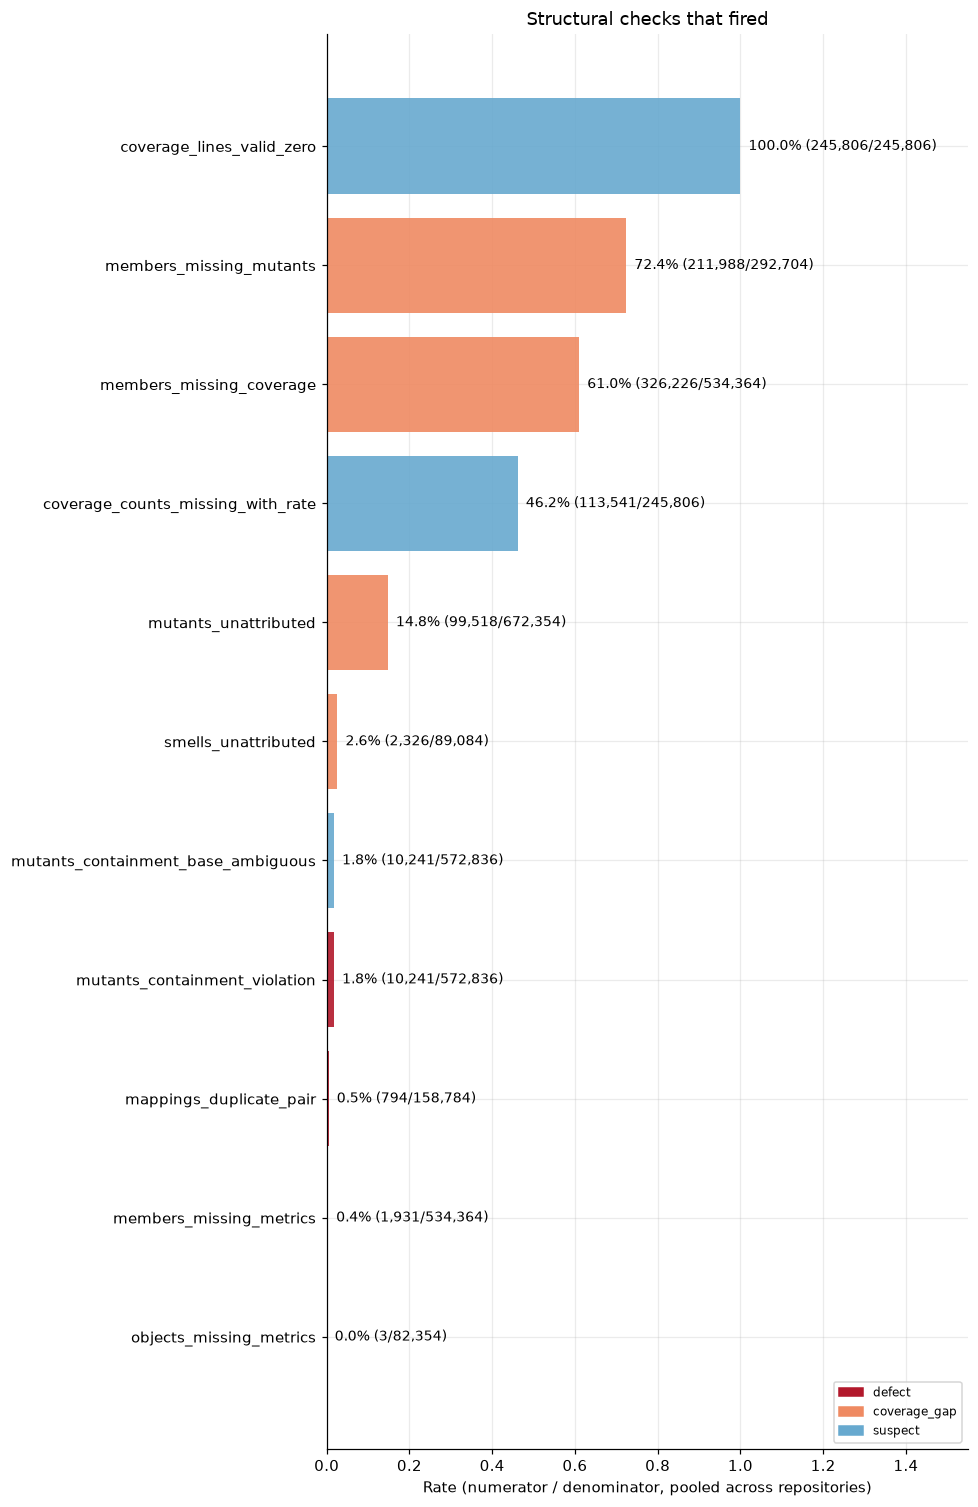

In [8]:
summary = summarize_checks(checks)
display(summary[summary["numerator"] > 0])

msr_plots.check_rate_bar(summary)
plt.tight_layout()
plt.show()

In [9]:
# Everything that came back clean. Worth reading: a check that is zero everywhere
# is either genuinely healthy or not actually exercised - confirm the denominator.
summary[summary["numerator"] == 0][["construct", "check", "denominator", "repositories"]]

,construct,check,denominator,repositories
2,code_metrics,metrics_duplicate_entity,614784,197
3,code_metrics,metrics_mi_out_of_range,614784,197
4,code_metrics,metrics_orphan_entity,614784,197
5,coverage,coverage_orphan_entity,245806,197
6,coverage,coverage_rate_out_of_range,245806,197
7,mappings,mappings_orphan_source,158784,184
8,mappings,mappings_orphan_test,158784,184
9,mappings,mappings_self_reference,158784,184
10,mutants,mutants_orphan_member,672354,116
11,test_smells,smells_containment_violation,86407,196


### Per-repository breakdown

Corpus rates hide concentration. A 3% defect rate spread evenly across every
repository is a systematic fault in the extractor; the same 3% concentrated in two
repositories is a property of those repositories. The distinction decides whether to
fix code or to stratify the sample.

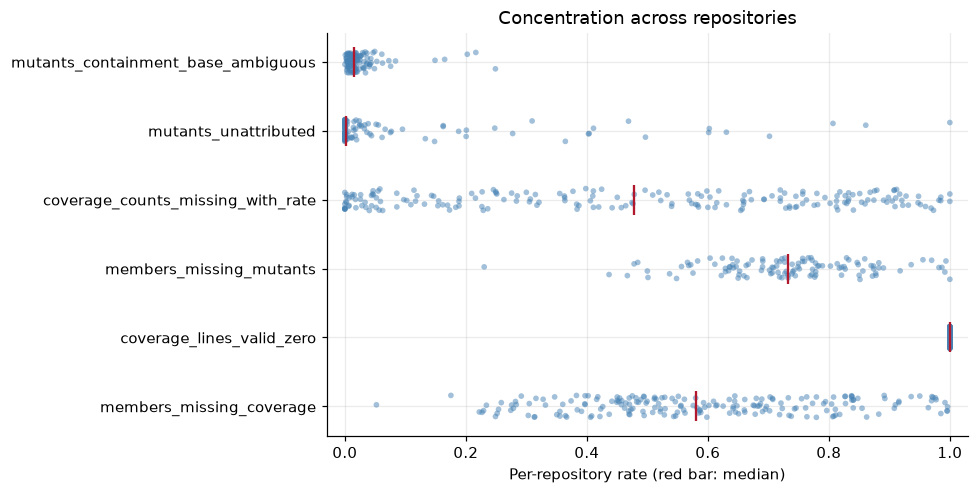

Top 5 repositories per missing-data check


,check,repo_key,numerator,denominator,rate
0,members_missing_coverage,joinrpg/joinrpg-net@075faf5460cd,8089,8119,0.9963
1,members_missing_coverage,openbullet/openbullet2@6b244ac7a584,11568,11617,0.9958
2,members_missing_coverage,eclipse-tractusx/portal-backend@fa5675c7e9d0,12732,12792,0.9953
3,members_missing_coverage,elsa-workflows/elsa-extensions@4b672e3b78a7,4454,4490,0.992
4,members_missing_coverage,avaloniaui/avalonia.samples@9e84fd03cb69,530,538,0.9851
5,members_missing_metrics,genaray/arch@4a959b8a63ed,173,1032,0.1676
6,members_missing_metrics,cysharp/zstring@e2b86f7ad433,60,661,0.09077
7,members_missing_metrics,mewssystems/funcsharp@cfca5628bfe0,296,3996,0.07407
8,members_missing_metrics,jamesmh/coravel@4072e041820f,43,937,0.04589
9,members_missing_metrics,genaray/arch.extended@18d1e4c1faec,35,794,0.04408


Top 5 repositories per defect check


,check,repo_key,numerator,denominator,rate
0,mappings_duplicate_pair,theolivenbaum/electron-sharp@2c0b299de26d,2,5,0.4
1,mappings_duplicate_pair,icsharpcode/ilspy-vscode@62b5908b16ae,60,251,0.239
2,mappings_duplicate_pair,coolnether123/rimworldmultiplayer@1e057df6d296,2,34,0.05882
3,mappings_duplicate_pair,c7-game/openciv3@d1d59861971d,15,278,0.05396
4,mappings_duplicate_pair,ppy/osu-server-spectator@e769ddd6021a,71,1768,0.04016
5,mutants_containment_violation,nbuilder/nbuilder@2769d20e112b,513,2061,0.2489
6,mutants_containment_violation,notion-dotnet/notion-sdk-net@6e82f3016dc4,155,716,0.2165
7,mutants_containment_violation,tintoy/dotnet-kube-client@6dccfe7e6733,1459,7210,0.2024
8,mutants_containment_violation,stoiveyp/slack.netstandard@815f2b3b4e41,491,2976,0.165
9,mutants_containment_violation,betalgo/openai@7c4859e368a2,332,2228,0.149


,repos_affected,total,max_repo_rate
check,,,
members_missing_coverage,197,326226,0.9963
coverage_lines_valid_zero,197,245806,1
members_missing_mutants,116,211988,1
coverage_counts_missing_with_rate,190,113541,1
mutants_unattributed,63,99518,1
mutants_containment_violation,115,10241,0.2489
mutants_containment_base_ambiguous,115,10241,0.2489
smells_unattributed,140,2326,0.3333
members_missing_metrics,84,1931,0.1676


In [10]:
def check_by_repo(check_name: str, top_n: int = 15) -> pd.DataFrame:
    rows = worst_repositories(checks, check_name, top_n=top_n)
    if rows.empty:
        print(f"[none] {check_name}")
    return rows

top_checks = (
    checks[checks["numerator"] > 0]
    .groupby("check")["numerator"].sum()
    .nlargest(6).index.tolist()
)
msr_plots.per_repo_rate_strip(checks, top_checks)
plt.tight_layout()
plt.show()

# Which repositories carry each gap. Ranked per check so a bad repository is
# named rather than left inside a pooled rate; ties on rate break on volume.
TOP_N = 5

def rank_repositories(severity: str, top_n: int = TOP_N) -> pd.DataFrame:
    subset = checks[(checks["severity"] == severity) & (checks["numerator"] > 0)]
    if subset.empty:
        return pd.DataFrame()
    return (
        subset.sort_values(["check", "rate", "numerator"], ascending=[True, False, False])
        .groupby("check", group_keys=False)
        .head(top_n)
        .loc[:, ["check", "repo_key", "numerator", "denominator", "rate"]]
        .reset_index(drop=True)
    )

print(f"Top {TOP_N} repositories per missing-data check")
display(rank_repositories("coverage_gap"))

print(f"Top {TOP_N} repositories per defect check")
display(rank_repositories("defect"))

affected = (
    checks[checks["numerator"] > 0]
    .groupby("check")
    .agg(repos_affected=("repo_key", "nunique"),
         total=("numerator", "sum"),
         max_repo_rate=("rate", "max"))
    .sort_values("total", ascending=False)
)
affected

## Code Metrics

TestMap collects code metrics through a custom library built on the Roslyn API,
persisted to `code_metrics` with an `entity_type` of `member` or `object`.

Aggregates are split by entity type: a class and a method are not the same
measurement, and pooling them makes both distributions unreadable.

In [11]:
# Shared for the four construct sections below.
#   attribution_summary - how many observations resolve to a code entity
#   rank_unattributed   - which repositories carry the failures
TOP_N_REPOS = 10

def attribution_summary(check_name: str, construct: str) -> pd.DataFrame:
    rows = checks[checks["check"] == check_name]
    if rows.empty:
        return pd.DataFrame()
    missing = int(rows["numerator"].sum())
    total = int(rows["denominator"].sum())
    return pd.DataFrame([{
        "construct": construct,
        "observations": total,
        "attributed": total - missing,
        "missing_attribution": missing,
        "attributed_pct": (total - missing) / total if total else float("nan"),
    }])

def rank_unattributed(check_name: str, top_n: int = TOP_N_REPOS) -> pd.DataFrame:
    rows = checks[(checks["check"] == check_name) & (checks["numerator"] > 0)]
    if rows.empty:
        print(f"[none] no repository fired {check_name}")
        return pd.DataFrame()
    return (
        rows.sort_values(["rate", "numerator"], ascending=False)
        .head(top_n)
        .loc[:, ["repo_key", "numerator", "denominator", "rate"]]
        .reset_index(drop=True)
    )

=== code_metrics / member (532,433 rows) ===


,column,count,missing,min,max,mean,median,std
0,maintainability_index,532433,0,0,100,87.21,93,14.75
1,cyclomatic_complexity,532433,0,0,895,1.519,1,3.387
2,class_coupling,532433,0,0,250,3.295,2,4.111
3,depth_of_inheritance,532433,0,0,0,0,0,0
4,source_lines_of_code,532433,0,1,10424,8.965,4,26.8
5,executable_lines_of_code,532433,0,0,2447,3.513,2,8.615


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,maintainability_index,532433,77,93,100,23,42.5,134.5,2263,0,0.00425
1,cyclomatic_complexity,532433,1,1,2,1,-0.5,3.5,0,31586,0.05932
2,class_coupling,532433,1,2,4,3,-3.5,8.5,0,49534,0.09303
3,depth_of_inheritance,532433,0,0,0,0,0,0,0,0,0
4,source_lines_of_code,532433,1,4,10,9,-12.5,23.5,0,43740,0.08215
5,executable_lines_of_code,532433,1,2,4,3,-3.5,8.5,0,54287,0.102


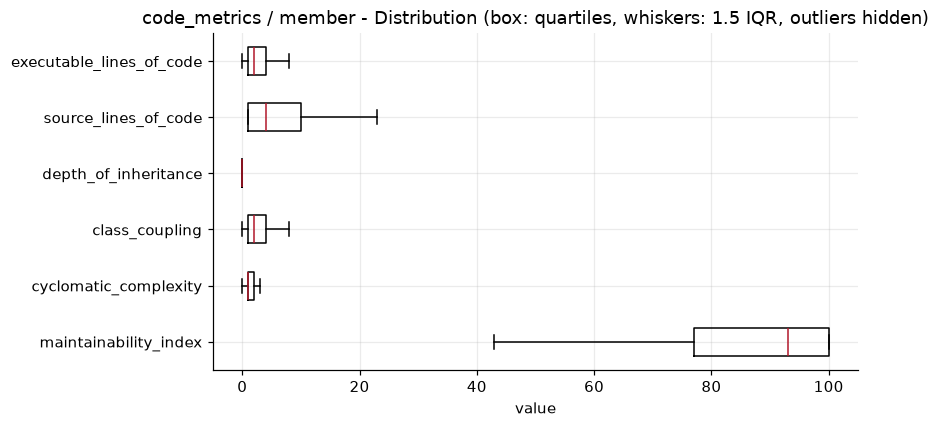

=== code_metrics / object (82,351 rows) ===


,column,count,missing,min,max,mean,median,std
0,maintainability_index,82351,0,0,100,83.51,85,14.04
1,cyclomatic_complexity,82351,0,0,2190,10.53,4,29.45
2,class_coupling,82351,0,0,1191,8.191,5,12.4
3,depth_of_inheritance,82351,0,0,10,1.266,1,0.8478
4,source_lines_of_code,82351,0,1,20207,80.67,24,313.9
5,executable_lines_of_code,82351,0,0,14523,25.7,6,105.1


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,maintainability_index,82351,73,85,97,24,37,133,261,0,0.003169
1,cyclomatic_complexity,82351,2,4,10,8,-10,22,0,8083,0.09815
2,class_coupling,82351,2,5,10,8,-10,22,0,5753,0.06986
3,depth_of_inheritance,82351,1,1,1,0,1,1,6070,18459,0.2979
4,source_lines_of_code,82351,10,24,64,54,-71,145,0,9537,0.1158
5,executable_lines_of_code,82351,2,6,20,18,-25,47,0,9519,0.1156


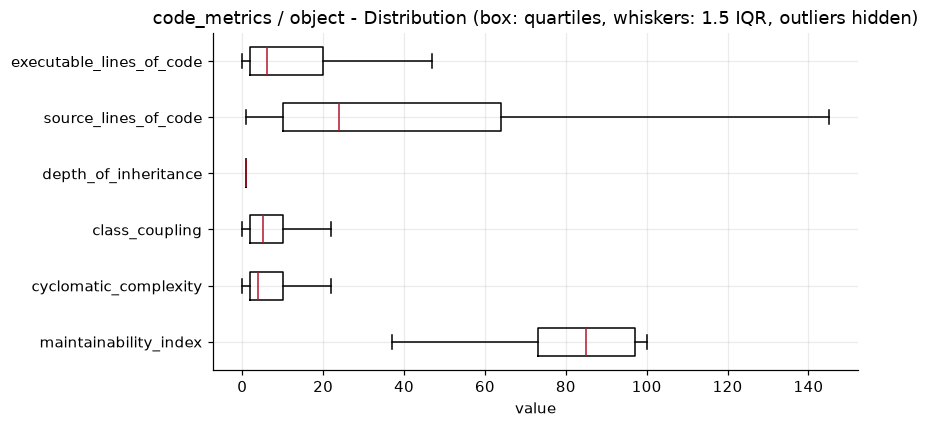

In [12]:
METRIC_COLS = NUMERIC_COLUMNS["code_metrics"]

for kind in ["member", "object"]:
    subset = code_metrics[code_metrics["entity_kind"] == kind]
    if subset.empty:
        continue
    print(f"=== code_metrics / {kind} ({len(subset):,} rows) ===")
    display(describe_numeric(subset, METRIC_COLS))
    display(iqr_table(subset, METRIC_COLS))
    ax = msr_plots.distribution_box(subset, METRIC_COLS)
    ax.set_title(f"code_metrics / {kind} - {ax.get_title()}")
    plt.tight_layout()
    plt.show()

In [13]:
# Attribution: a metric row points at an entity_id that must exist. Missing
# attribution here means the row survived but its entity did not.
#
# Same caveat as coverage below: this detects dangling references, not entries the
# mapper skipped. Members that never received a metric row are the complementary
# measure, ranked second.
display(attribution_summary("metrics_orphan_entity", "code_metrics"))
print("repositories ranked by metric rows pointing at a missing entity")
display(rank_unattributed("metrics_orphan_entity"))
print("repositories ranked by members carrying no metric row at all")
display(rank_unattributed("members_missing_metrics"))

,construct,observations,attributed,missing_attribution,attributed_pct
0,code_metrics,614784,614784,0,1


repositories ranked by metric rows pointing at a missing entity
[none] no repository fired metrics_orphan_entity


""


repositories ranked by members carrying no metric row at all


,repo_key,numerator,denominator,rate
0,genaray/arch@4a959b8a63ed,173,1032,0.1676
1,cysharp/zstring@e2b86f7ad433,60,661,0.09077
2,mewssystems/funcsharp@cfca5628bfe0,296,3996,0.07407
3,jamesmh/coravel@4072e041820f,43,937,0.04589
4,genaray/arch.extended@18d1e4c1faec,35,794,0.04408
5,apache/casbin-casbin.net@eeb44055b7e3,74,1836,0.04031
6,mapstermapper/mapster@cbc1e5f04e6e,107,3538,0.03024
7,m-files/vaf.extensions.community@df473237c129,48,1886,0.02545
8,tyrrrz/lightbulb@95af6760fe68,10,499,0.02004
9,paillave/etl.net@21c3a6d9518d,105,5247,0.02001


## Test Smells

Smells come from an xNose-based detector. `TestSmellService` attributes each finding
to a member by file path plus nearest start line, breaking ties on the newest member
id — so stale member rows left by earlier generated attempts can win, and that is the
risk stratum for the manual attribution sheet.

The aggregate is per smell type, measured as findings per repository: the corpus
total says which smells are common, the spread says whether that is a few
repositories or all of them.

,smell_name,column,count,missing,min,max,mean,median,std
0,Assertion Roulette Test Smell,findings,149,0,1,960,83.48,38,137.4
1,Bool In Assert Equal Test Smell,findings,10,0,1,7,3.4,2,2.633
2,Conditional Test Smell,findings,164,0,1,171,21.77,9,31.36
3,Cyclomatic Complexity Test Smell,findings,18,0,1,5,1.722,1,1.074
4,Duplicate Assertion Test Smell,findings,192,0,1,1147,103.9,52,152.3
5,Eager Test Smell,findings,192,0,1,2539,196.6,93.5,331.5
6,Empty Test Smell,findings,20,0,1,11,2.35,1,2.641
7,Equal In Assert Test Smell,findings,63,0,1,55,7.952,4,9.582
8,Expected Exception Test Smell,findings,9,0,1,196,41.44,6,65.03
9,Ignored Test Smell,findings,51,0,1,46,5.078,2,8.087


,smell_name,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,Assertion Roulette Test Smell,findings,149,12,38,96,84,-114,222,0,14,0.09396
1,Bool In Assert Equal Test Smell,findings,10,1.25,2,6.25,5,-6.25,13.75,0,0,0
2,Conditional Test Smell,findings,164,3,9,27.25,24.25,-33.38,63.62,0,14,0.08537
3,Cyclomatic Complexity Test Smell,findings,18,1,1,2,1,-0.5,3.5,0,1,0.05556
4,Duplicate Assertion Test Smell,findings,192,20,52,107.5,87.5,-111.2,238.8,0,22,0.1146
5,Eager Test Smell,findings,192,40.25,93.5,198.2,158,-196.8,435.2,0,17,0.08854
6,Empty Test Smell,findings,20,1,1,2.25,1.25,-0.875,4.125,0,2,0.1
7,Equal In Assert Test Smell,findings,63,2,4,10,8,-10,22,0,5,0.07937
8,Expected Exception Test Smell,findings,9,1,6,48,47,-69.5,118.5,0,1,0.1111
9,Ignored Test Smell,findings,51,1,2,5,4,-5,11,0,5,0.09804


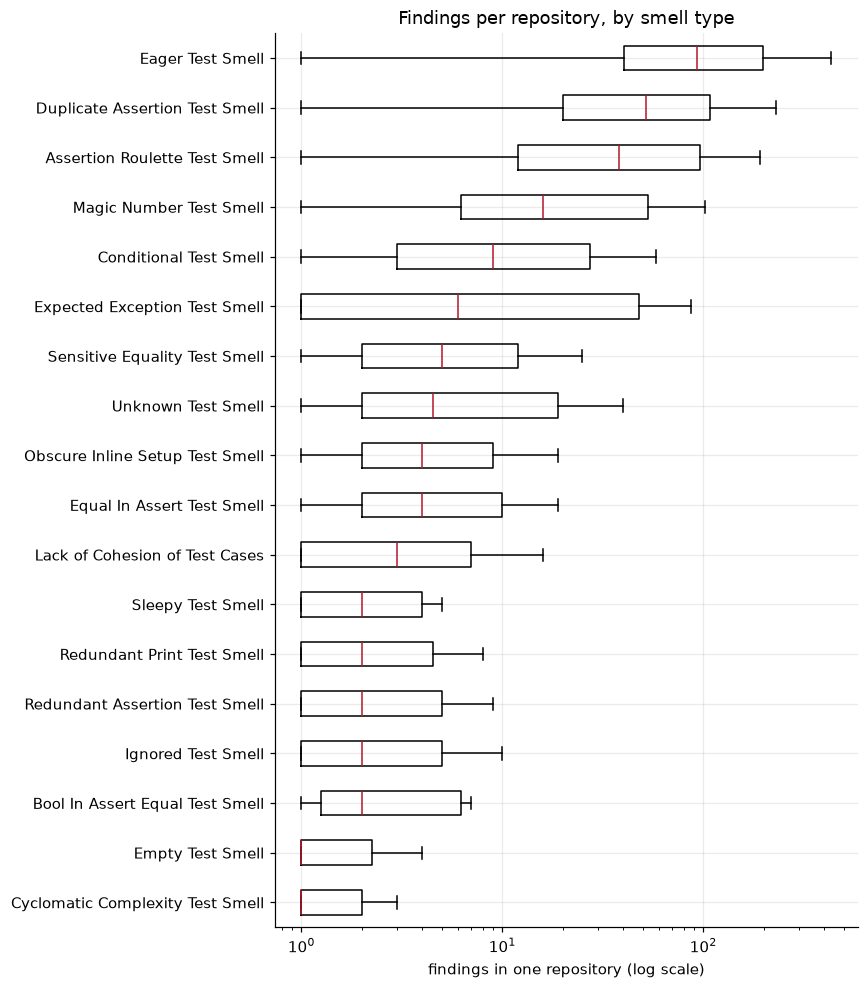

In [14]:
if not test_smells.empty:
    per_repo_type = (
        test_smells.groupby(["repo_key", "smell_name"])
        .size().rename("findings").reset_index()
    )
    display(describe_numeric(per_repo_type, ["findings"], by="smell_name"))
    display(iqr_table(per_repo_type, ["findings"], by="smell_name"))
    msr_plots.grouped_box(per_repo_type, "findings", "smell_name",
                          title="Findings per repository, by smell type",
                          xlabel="findings in one repository")
    plt.tight_layout()
    plt.show()

,findings,share_of_all,repositories
smell_name,,,
Eager Test Smell,37755,0.4238,192
Duplicate Assertion Test Smell,19954,0.224,192
Assertion Roulette Test Smell,12439,0.1396,149
Magic Number Test Smell,7579,0.08508,158
Conditional Test Smell,3571,0.04009,164
Unknown Test Smell,2850,0.03199,126
Sensitive Equality Test Smell,1347,0.01512,101
Lack of Cohesion of Test Cases,970,0.01089,139
Obscure Inline Setup Test Smell,893,0.01002,101


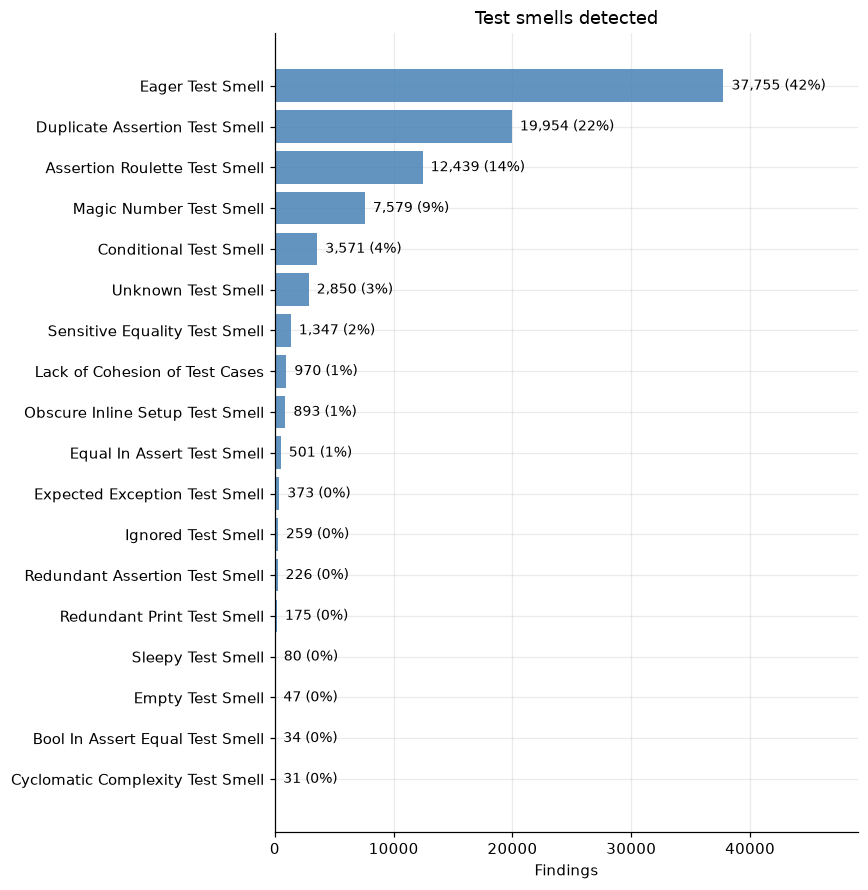

In [15]:
# Distribution across types: what share of all findings each smell accounts for.
if not test_smells.empty:
    smell_dist = (
        test_smells["smell_name"].value_counts().rename("findings").to_frame()
        .assign(share_of_all=lambda d: d["findings"] / d["findings"].sum(),
                repositories=lambda d: test_smells.groupby("smell_name")["repo_key"]
                                                  .nunique().reindex(d.index))
    )
    display(smell_dist)
    msr_plots.category_bar(test_smells["smell_name"].value_counts(),
                           "Test smells detected", "Findings", top_n=25)
    plt.tight_layout()
    plt.show()

In [16]:
# Attribution: member_id and object_id are both nullable, so a finding can land
# on no entity at all.
display(attribution_summary("smells_unattributed", "test_smells"))
print("repositories ranked by unattributed smell rate")
display(rank_unattributed("smells_unattributed"))

,construct,observations,attributed,missing_attribution,attributed_pct
0,test_smells,89084,86758,2326,0.9739


repositories ranked by unattributed smell rate


,repo_key,numerator,denominator,rate
0,particular/particular.analyzers@d991860eed22,1,3,0.3333
1,tryagi/langchain@26bb1d16d614,45,169,0.2663
2,digitalruby/ipban@55be9aae8d12,261,990,0.2636
3,nodatime/nodatime@d3964660c577,451,1859,0.2426
4,azure-samples/iot-edge-opc-plc@f8b07ce2b659,62,278,0.223
5,taosdata/taos-connector-dotnet@930f64a4f1bd,127,585,0.2171
6,m-files/vaf.extensions.community@df473237c129,146,827,0.1765
7,infocaster/urltracker@bad768d4465f,10,82,0.122
8,cucumber/messages@4c925b936151,2,17,0.1176
9,hypar-io/elements@d4e7a95266e6,180,1900,0.09474


## Code Coverage

Coverage is parsed from Cobertura reports produced by `dotnet test` and mapped onto
members and objects.

**The coverage report is not under validation here.** The rate is taken from the
report as recorded — this study does not re-derive it, and does not attempt to
establish whether `dotnet test` measured coverage correctly. That is the coverage
tool's business, and it is carried as a threat rather than a result. What this pass
validates for coverage is **attribution**: whether a rate that the report produced
was attached to the right member.

Only `line_rate` and `branch_rate` are described. The count columns
(`lines_covered`, `lines_valid`, and the branch equivalents) are not persisted on
per-entity rows — a bug, recorded in `../msr_validation_bugs.md` — so their
distributions would describe the bug rather than the corpus.

,column,count,missing,min,max,mean,median,std
0,line_rate,245806,0,0,1,0.4404,0,0.4844
1,branch_rate,245806,0,0,1,0.8252,1,0.3627


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,line_rate,245806,0,0,1,1,-1.5,2.5,0,0,0
1,branch_rate,245806,1,1,1,0,1,1,52551,0,0.2138


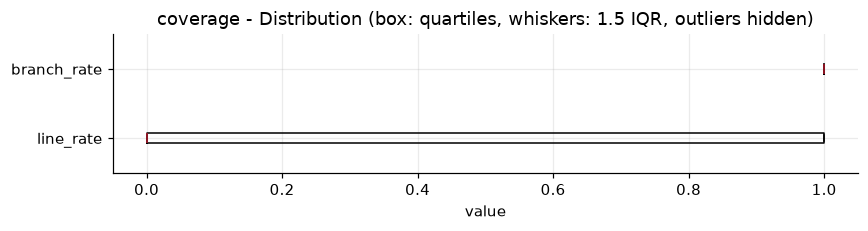

by entity type


,entity_kind,column,count,missing,min,max,mean,median,std
0,member,line_rate,208634,0,0,1,0.4385,0,0.4881
1,member,branch_rate,208634,0,0,1,0.8411,1,0.3509
2,object,line_rate,37172,0,0,1,0.4508,0.2644,0.4624
3,object,branch_rate,37172,0,0,1,0.7356,1,0.4115


,entity_kind,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,member,line_rate,208634,0,0,1,1,-1.5,2.5,0,0,0
1,member,branch_rate,208634,1,1,1,0,1,1,39724,0,0.1904
2,object,line_rate,37172,0,0.2644,1,1,-1.5,2.5,0,0,0
3,object,branch_rate,37172,0.5,1,1,0.5,-0.25,1.75,0,0,0


In [17]:
COVERAGE_COLS = ["line_rate", "branch_rate"]

if not coverage.empty:
    display(describe_numeric(coverage, COVERAGE_COLS))
    display(iqr_table(coverage, COVERAGE_COLS))
    ax = msr_plots.distribution_box(coverage, COVERAGE_COLS, log=False)
    ax.set_title(f"coverage - {ax.get_title()}")
    plt.tight_layout()
    plt.show()

    print("by entity type")
    display(describe_numeric(coverage, COVERAGE_COLS, by="entity_kind"))
    display(iqr_table(coverage, COVERAGE_COLS, by="entity_kind"))

In [18]:
# Attribution, with a caveat that has to be read with the number.
#
# This measures dangling references only: does a persisted coverage row point at
# an entity that exists. It CANNOT detect a report entry the mapper failed to
# match, because that path logs a warning and skips - no row, no null, nothing in
# the database. So a 100% result here is true by construction, not evidence of a
# clean mapping. The real completeness figure comes from the run logs and is
# about 79% (see bug 6 in ../msr_validation_bugs.md).
display(attribution_summary("coverage_orphan_entity", "coverage"))
print("repositories ranked by coverage rows pointing at a missing entity")
display(rank_unattributed("coverage_orphan_entity"))

# The complementary question - members that never received a coverage row - is a
# different measurement and is dominated by projects the test run never
# instrumented, so it is ranked separately rather than folded into the rate above.
print("repositories ranked by members carrying no coverage row")
display(rank_unattributed("members_missing_coverage"))

,construct,observations,attributed,missing_attribution,attributed_pct
0,coverage,245806,245806,0,1


repositories ranked by coverage rows pointing at a missing entity
[none] no repository fired coverage_orphan_entity


""


repositories ranked by members carrying no coverage row


,repo_key,numerator,denominator,rate
0,joinrpg/joinrpg-net@075faf5460cd,8089,8119,0.9963
1,openbullet/openbullet2@6b244ac7a584,11568,11617,0.9958
2,eclipse-tractusx/portal-backend@fa5675c7e9d0,12732,12792,0.9953
3,elsa-workflows/elsa-extensions@4b672e3b78a7,4454,4490,0.992
4,avaloniaui/avalonia.samples@9e84fd03cb69,530,538,0.9851
5,linkdotnet/blog@f622d4e91bd3,1162,1189,0.9773
6,jasperfx/lamar@7361b4c20cab,2822,2891,0.9761
7,tyrrrz/lightbulb@95af6760fe68,485,499,0.9719
8,encamina/enmarcha@3a1262151005,2455,2530,0.9704
9,genaray/arch.extended@18d1e4c1faec,770,794,0.9698


In [19]:
# The persistence bug, kept visible: rates without their counts.
print("coverage rows with a rate but no counts")
display(check_by_repo("coverage_counts_missing_with_rate"))
print("coverage rows where lines_valid is zero")
display(check_by_repo("coverage_lines_valid_zero"))

coverage rows with a rate but no counts


,repo_key,check,numerator,denominator,rate
0,gustavopsantos/reflex@55423389e8d4,coverage_counts_missing_with_rate,14,14,1
1,seesharper/lightinject@2fd34389552d,coverage_counts_missing_with_rate,510,510,1
2,error-or/error-or@7b18de9b9441,coverage_counts_missing_with_rate,66,67,0.9851
3,onizet/html2openxml@7380a76be250,coverage_counts_missing_with_rate,590,599,0.985
4,particular/particular.analyzers@d991860eed22,coverage_counts_missing_with_rate,327,333,0.982
5,vonage/vonage-dotnet-sdk@8cad0859af71,coverage_counts_missing_with_rate,3388,3482,0.973
6,nodatime/nodatime@d3964660c577,coverage_counts_missing_with_rate,4375,4515,0.969
7,oras-project/oras-dotnet@034b059bbbef,coverage_counts_missing_with_rate,811,845,0.9598
8,tyrrrz/cliwrap@9faa26f2a68a,coverage_counts_missing_with_rate,137,144,0.9514
9,tylerbrinks/sqlparser-cs@e1929977a962,coverage_counts_missing_with_rate,1173,1237,0.9483


coverage rows where lines_valid is zero


,repo_key,check,numerator,denominator,rate
0,a2aproject/a2a-dotnet@8fe65cfaa65a,coverage_lines_valid_zero,513,513,1
1,aalhour/c-sharp-algorithms@b82432474a91,coverage_lines_valid_zero,1262,1262,1
2,alirezanet/gridify@2d6b9b3fe66f,coverage_lines_valid_zero,1093,1093,1
3,allegro/dotnet-utils@3c8324a41ddb,coverage_lines_valid_zero,143,143,1
4,amberg/docxtemplater@35f07b7cc708,coverage_lines_valid_zero,452,452,1
5,anglesharp/anglesharp.css@346610304010,coverage_lines_valid_zero,4114,4114,1
6,apache/arrow-adbc@254ea1cfe7c6,coverage_lines_valid_zero,458,458,1
7,apache/casbin-casbin.net@eeb44055b7e3,coverage_lines_valid_zero,792,792,1
8,apache/pulsar-dotpulsar@d72d04426783,coverage_lines_valid_zero,1160,1160,1
9,arcus-azure/arcus.observability@9c12bf295de8,coverage_lines_valid_zero,300,300,1


## Mutation Score

Mutants come from Stryker.NET and are mapped to members. The consolidated frame is
aggregated per `(member, report)` with one column per mutant status — the raw
per-mutant table runs to millions of rows across the corpus, and sampling re-reads
individual mutants from the originating database.

The aggregate below is therefore per member: how many mutants one member carries,
and how they resolve. `mutants_containment_violation` counts mutants whose reported
line falls outside the span of the member they were attributed to; where it equals
`mutants_containment_base_ambiguous`, every violation is a one-line boundary case
and the line-base convention is the thing to check, not the mapping.

,column,count,missing,min,max,mean,median,std
0,mutants_total,81646,0,1,1295,7.016,3,15.5
1,killed,81646,0,0,1292,1.306,0,6.481
2,survived,81646,0,0,607,0.9328,0,5.761
3,nocoverage,81646,0,0,1245,2.917,1,9.552
4,compileerror,81646,0,0,444,0.4637,0,3.275
5,ignored,81646,0,0,259,1.323,1,2.536
6,timeout,81646,0,0,145,0.07354,0,1.052
7,static_mutants,81646,0,0,765,0.2588,0,3.82
8,distinct_mutators,81646,0,1,21,3.038,3,2.205


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,mutants_total,81646,1,3,7,6,-8,16,0,8163,0.09998
1,killed,81646,0,0,1,1,-1.5,2.5,0,10067,0.1233
2,survived,81646,0,0,0,0,0,0,0,18812,0.2304
3,nocoverage,81646,0,1,2,2,-3,5,0,9482,0.1161
4,compileerror,81646,0,0,0,0,0,0,0,9788,0.1199
5,ignored,81646,0,1,1,1,-1.5,2.5,0,10401,0.1274
6,timeout,81646,0,0,0,0,0,0,0,2177,0.02666
7,static_mutants,81646,0,0,0,0,0,0,0,4784,0.05859
8,distinct_mutators,81646,1,3,4,3,-3.5,8.5,0,2569,0.03147


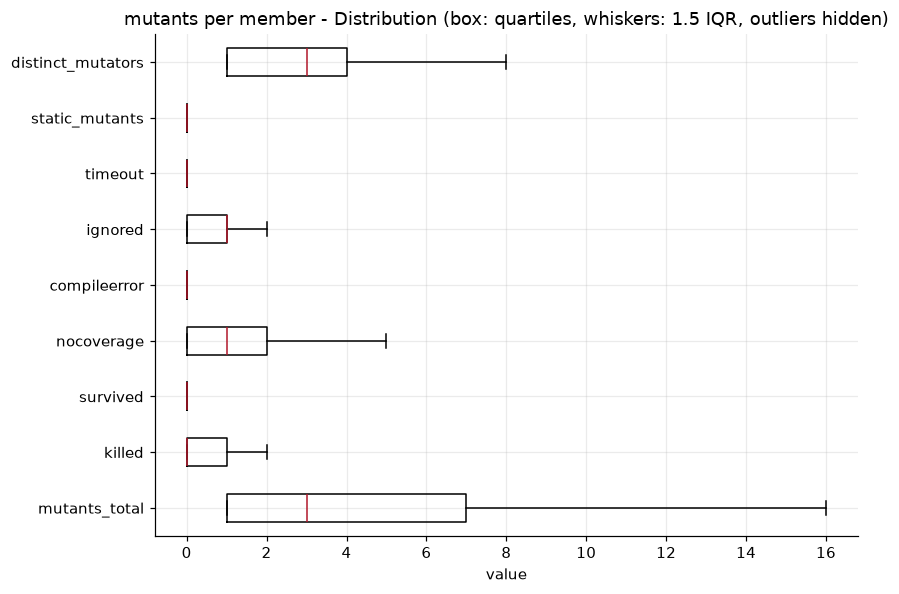

In [20]:
MUTANT_COLS = NUMERIC_COLUMNS["mutants"]

if not mutants.empty:
    display(describe_numeric(mutants, MUTANT_COLS))
    display(iqr_table(mutants, MUTANT_COLS))
    ax = msr_plots.distribution_box(mutants, MUTANT_COLS, log=False)
    ax.set_title(f"mutants per member - {ax.get_title()}")
    plt.tight_layout()
    plt.show()

,mutants,share_of_all
killed,106593,0.1861
survived,76158,0.1329
nocoverage,238187,0.4158
compileerror,37862,0.0661
ignored,108032,0.1886
timeout,6004,0.01048


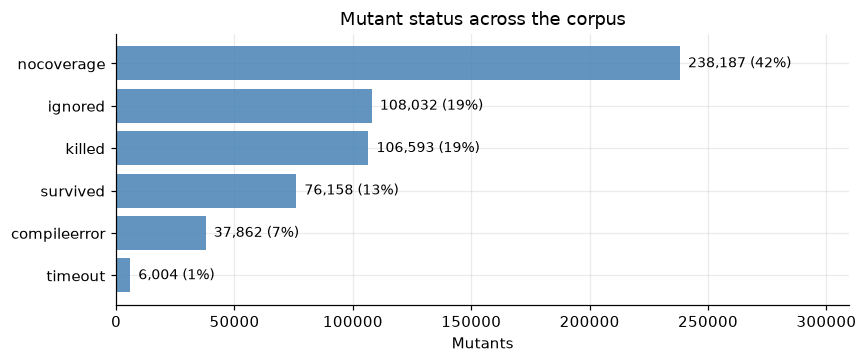

scored (killed + survived): 182,751 of 572,836 (31.9%)


In [21]:
# Distribution across statuses: what share of all mutants each outcome accounts
# for. 'killed / (killed + survived)' is not the same denominator as
# 'killed / total' once NoCoverage, CompileError, Ignored, and Timeout are present.
if not mutants.empty:
    status_cols = ["killed", "survived", "nocoverage", "compileerror", "ignored", "timeout"]
    status_dist = mutants[status_cols].sum().rename("mutants").to_frame()
    status_dist["share_of_all"] = status_dist["mutants"] / status_dist["mutants"].sum()
    display(status_dist)
    msr_plots.category_bar(status_dist["mutants"], "Mutant status across the corpus", "Mutants")
    plt.tight_layout()
    plt.show()

    scored = int(status_dist.loc[["killed", "survived"], "mutants"].sum())
    total = int(status_dist["mutants"].sum())
    print(f"scored (killed + survived): {scored:,} of {total:,} ({scored / total:.1%})")

In [22]:
# Attribution: member_id is nullable, so Stryker can report a mutant TestMap
# cannot place on any entity.
display(attribution_summary("mutants_unattributed", "mutants"))
print("repositories ranked by unattributed mutant rate")
display(rank_unattributed("mutants_unattributed"))
print("repositories ranked by members carrying no mutants")
display(rank_unattributed("members_missing_mutants"))

,construct,observations,attributed,missing_attribution,attributed_pct
0,mutants,672354,572836,99518,0.852


repositories ranked by unattributed mutant rate


,repo_key,numerator,denominator,rate
0,videokojot/efcore.bulkextensions.mit@ce220063a522,9566,9566,1
1,genaray/arch@4a959b8a63ed,10301,11964,0.861
2,ardalis/guardclauses@41162c469462,284,352,0.8068
3,error-or/error-or@7b18de9b9441,259,369,0.7019
4,opentok/opentok-.net-sdk@e1fe5e665863,1214,1925,0.6306
5,luca-piccioni/opengl.net@b64077490b5d,37934,62974,0.6024
6,cysharp/zstring@e2b86f7ad433,9930,16512,0.6014
7,mattosaurus/pgpcore@d5efce26a821,1113,2240,0.4969
8,neo-project/neo-vm@99095c26663c,1068,2278,0.4688
9,mattpannella/pupdate@07452a17af89,3474,8453,0.411


repositories ranked by members carrying no mutants


,repo_key,numerator,denominator,rate
0,videokojot/efcore.bulkextensions.mit@ce220063a522,1099,1099,1
1,handlebars-net/handlebars.net.helpers@3cc25961...,924,930,0.9935
2,shipengine/shipengine-dotnet@ff04c26f2a26,5186,5229,0.9918
3,noscoreio/noscore.packets@b759975a8cdb,5611,5685,0.987
4,simplcommerce/simplcommerce@3472ba02a6f2,3871,3942,0.982
5,tyrrrz/lightbulb@95af6760fe68,484,499,0.9699
6,yellow-dog-man/resonitelink@067afad3d197,1483,1552,0.9555
7,ruslan-b/ffmpeg.autogen@444925cd53d3,527,563,0.9361
8,ardalis/guardclauses@41162c469462,581,633,0.9179
9,qowaiv/qowaiv@8a64b2447ab3,5748,6457,0.8902


## Source To Test Mappings

Mappings come from Roslyn semantic traces, persisted with an evidence kind, a path
length and a chain of trace steps.

What this pass checks is shape, not correctness: that `(source_member_id,
test_member_id)` is unique, and that mappings point the right way.
`mappings_source_is_test_member` and `mappings_test_not_test_member` catch a source
that is itself a test method, or a test end that is not a test member. Whether a
mapping describes a test that genuinely exercises the member is a rater question,
not one the frames can answer.

In [23]:
for check in ["mappings_duplicate_pair",
              "mappings_source_is_test_member", "mappings_test_not_test_member"]:
    print(check)
    display(check_by_repo(check, top_n=10))

mappings_duplicate_pair


,repo_key,check,numerator,denominator,rate
0,theolivenbaum/electron-sharp@2c0b299de26d,mappings_duplicate_pair,2,5,0.4
1,icsharpcode/ilspy-vscode@62b5908b16ae,mappings_duplicate_pair,60,251,0.239
2,coolnether123/rimworldmultiplayer@1e057df6d296,mappings_duplicate_pair,2,34,0.05882
3,c7-game/openciv3@d1d59861971d,mappings_duplicate_pair,15,278,0.05396
4,ppy/osu-server-spectator@e769ddd6021a,mappings_duplicate_pair,71,1768,0.04016
5,cmllib/cmllib.core@55f1cb9f3261,mappings_duplicate_pair,10,278,0.03597
6,github/gh-gei@230bba8a65f5,mappings_duplicate_pair,16,497,0.03219
7,ubisoft/ngitlab@a8fec69e9254,mappings_duplicate_pair,166,5229,0.03175
8,net-daemon/netdaemon@ca717d7aba6c,mappings_duplicate_pair,25,859,0.0291
9,yellowfeather/dbfdatareader@4f6ac3e29a65,mappings_duplicate_pair,35,1655,0.02115


mappings_source_is_test_member


,repo_key,check,numerator,denominator,rate
0,a2aproject/a2a-dotnet@8fe65cfaa65a,mappings_source_is_test_member,0,425,0
1,aalhour/c-sharp-algorithms@b82432474a91,mappings_source_is_test_member,0,211,0
2,alirezanet/gridify@2d6b9b3fe66f,mappings_source_is_test_member,0,1660,0
3,allegro/dotnet-utils@3c8324a41ddb,mappings_source_is_test_member,0,2,0
4,amberg/docxtemplater@35f07b7cc708,mappings_source_is_test_member,0,1014,0
5,anglesharp/anglesharp.css@346610304010,mappings_source_is_test_member,0,2572,0
6,apache/arrow-adbc@254ea1cfe7c6,mappings_source_is_test_member,0,465,0
7,apache/casbin-casbin.net@eeb44055b7e3,mappings_source_is_test_member,0,614,0
8,apache/pulsar-dotpulsar@d72d04426783,mappings_source_is_test_member,0,2116,0
9,arcus-azure/arcus.observability@9c12bf295de8,mappings_source_is_test_member,0,153,0


mappings_test_not_test_member


,repo_key,check,numerator,denominator,rate
0,a2aproject/a2a-dotnet@8fe65cfaa65a,mappings_test_not_test_member,0,425,0
1,aalhour/c-sharp-algorithms@b82432474a91,mappings_test_not_test_member,0,211,0
2,alirezanet/gridify@2d6b9b3fe66f,mappings_test_not_test_member,0,1660,0
3,allegro/dotnet-utils@3c8324a41ddb,mappings_test_not_test_member,0,2,0
4,amberg/docxtemplater@35f07b7cc708,mappings_test_not_test_member,0,1014,0
5,anglesharp/anglesharp.css@346610304010,mappings_test_not_test_member,0,2572,0
6,apache/arrow-adbc@254ea1cfe7c6,mappings_test_not_test_member,0,465,0
7,apache/casbin-casbin.net@eeb44055b7e3,mappings_test_not_test_member,0,614,0
8,apache/pulsar-dotpulsar@d72d04426783,mappings_test_not_test_member,0,2116,0
9,arcus-azure/arcus.observability@9c12bf295de8,mappings_test_not_test_member,0,153,0


,mappings,repos,mean_path_length
evidence_kind,,,
DirectMethodInvocation,99273,180,1
HelperMediatedPath,43146,134,2.374
DirectConstructorInvocation,16365,158,1


,column,count,missing,min,max,mean,median,std
0,path_length,158784,0,1,4,1.373,1,0.6828


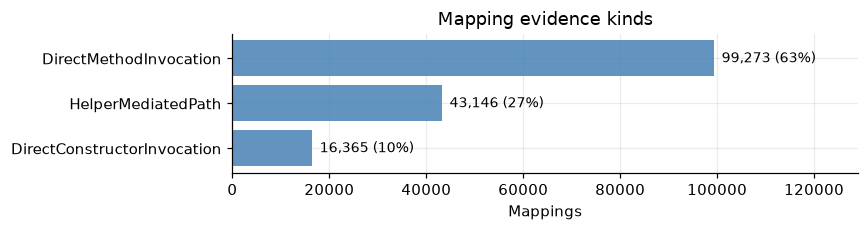

In [24]:
if not mappings.empty:
    display(
        mappings.groupby("evidence_kind")
        .agg(mappings=("observation_id", "size"),
             repos=("repo_key", "nunique"),
             mean_path_length=("path_length", "mean"))
        .sort_values("mappings", ascending=False)
    )
    display(describe_numeric(mappings, ["path_length"]))

    msr_plots.category_bar(mappings["evidence_kind"].value_counts(),
                           "Mapping evidence kinds", "Mappings")
    plt.tight_layout()
    plt.show()

In [25]:
# Mapping recall frame: production members with no mapping at all. This is the
# complement stratum - precision sampling cannot see it.
if not mappings.empty and not entities.empty:
    scoped = set(mappings["repo_key"])
    prod = entities[
        (entities["entity_kind"] == "member")
        & (entities["is_test"] == 0)
        & (entities["repo_key"].isin(scoped))
    ]
    mapped = set(zip(mappings["repo_key"], mappings["source_member_id"]))
    prod = prod.assign(has_mapping=[(r, e) in mapped for r, e in zip(prod["repo_key"], prod["entity_id"])])
    print(f"production members: {len(prod):,}  with a mapping: {int(prod['has_mapping'].sum()):,} "
          f"({prod['has_mapping'].mean():.1%})")
    display(
        prod.groupby("kind")["has_mapping"]
        .agg(members="size", mapped="sum")
        .assign(mapped_rate=lambda d: d["mapped"] / d["members"])
        .sort_values("members", ascending=False)
    )

production members: 431,969  with a mapping: 18,890 (4.4%)


,members,mapped,mapped_rate
kind,,,
method,166680,16603,0.09961
property,132430,0,0
field,102540,0,0
constructor,26779,2287,0.0854
operator,1213,0,0
conversion_operator,994,0,0
event,917,0,0
static_constructor,362,0,0
destructor,54,0,0


## What This Pass Decides

Before any sampling starts, three questions should have answers from the tables above:

1. **Which constructs are healthy enough to sample?** A construct with a systematic
   fault should be fixed first — sampling it measures the fault, not the instrument.
2. **What are the real denominators?** Availability differs sharply per construct, and
   the per-construct rater budget in the plan assumes a population that actually exists.
3. **Where do the defects concentrate?** Evenly spread means fix the extractor;
   concentrated in a few repositories means stratify the sample.

A fourth question the tables cannot answer, by design: **are the recorded values
right?** Coverage rates and mutation statuses are taken from their tools as recorded.
This pass validates that TestMap read them, kept them, and attached them to the right
code — not that `dotnet test` and Stryker measured them correctly. Tool-level
measurement error is a threat carried into the study, not a result established here.

Findings that change the plan belong in `../msr_validation_plan.md`; bugs go to
`../msr_validation_bugs.md`.

**All six bugs recorded there are to be fixed before the full evaluation run.** That
is what this pass was for: none of them has corrupted a reported result yet, and all
of them would have if the full evaluation had gone first.

One caveat carries into that work. Two of the attribution rates above read 100% —
coverage and code metrics — and neither is evidence of a clean mapping. Both mappers
warn and skip when they cannot match an entry, so a failure never becomes a row and
no database check can see it. Measured from the run logs instead, coverage mapping
drops about 21% of the entries its reports offered. Until those failures are
persisted rather than logged, treat a clean attribution rate on those two constructs
as unmeasured, not as passing.